# PyTorch арқылы Машиналық Оқыту: толық практикалық нұсқаулық

Бұл ноутбукта сіз PyTorch кітапханасын қолданып, машиналық оқытудың барлық негізгі кезеңдерін — деректерді жүктеу, алдын ала өңдеу, модель құру, үйрету, бағалау және нәтижелерді талдауды — практикада меңгересіз.

**Деректер жиыны:** Wine Quality (ақ шарап сапасы) — UCI репозиторийіндегі орта мөлшерлі классификация есебі.  
**Тапсырма:** Шараптың физико-химиялық сипаттамалары бойынша оның сапасын болжау (регрессия, содан кейін классификация).




**Ноутбук құрылымы:**

1. Ортаны дайындау және кітапханаларды импорттау  
2. Деректерді жүктеу және зерттеу (EDA)  
3. Деректерді алдын ала өңдеу  
4. PyTorch Dataset және DataLoader  
5. Нейрондық желіні құру  
6. Жоғалту функциясы және оптимизатор  
7. Үйрету циклі  
8. Бағалау және нәтижелерді талдау  
9. Гиперпараметрлермен тәжірибе  
10. Модельді сақтау және жүктеу



## 1-бөлім. Ортаны дайындау және кітапханаларды импорттау

**Мақсат:** Жұмыс ортасын баптап, қажетті кітапханаларды жүктеу және PyTorch нұсқасын тексеру.

In [2]:
# Негізгі кітапханаларды импорттау
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

# Визуализация параметрлері
matplotlib.rcParams['figure.figsize'] = (10, 5)
matplotlib.rcParams['font.size'] = 12
sns.set_style('whitegrid')

# Қайталану үшін random seed орнату
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'PyTorch нұсқасы: {torch.__version__}')
print(f'CUDA қолжетімді: {torch.cuda.is_available()}')

# Есептеу құрылғысын анықтау
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Қолданылатын құрылғы: {device}')

PyTorch нұсқасы: 2.10.0+cpu
CUDA қолжетімді: False
Қолданылатын құрылғы: cpu


### Тапсырма 1.1

Төмендегі бос орындарды толтырыңыз:

- `torch.__version__` нені білдіреді?
- CUDA дегеніміз не және ол неге маңызды?
- `torch.manual_seed(SEED)` қандай мақсатта қолданылады?

Жауабыңызды осы Markdown ұяшығына жазыңыз:

**Жауап:**  
*(осында жазыңыз)*

In [3]:
# Тапсырма 1.2: Torch тензор операциялары
# TODO: 3x4 өлшемді кездейсоқ тензор жасаңыз
t1 = torch.rand(3,4)
print('Тензор:')
print(t1)
print(f'Өлшемі (shape): {t1.shape}')
print(f'Деректер типі (dtype): {t1.dtype}')

# TODO: Тензордың орташа мәнін, стандартты ауытқуын, минимум және максимумын шығарыңыз
print(f'\nОрташа мән: {t1.mean()}')   # TODO
print(f'Стандартты ауытқу: {t1.std()}')  # TODO
print(f'Минимум: {t1.min()}')  # TODO
print(f'Максимум: {t1.max()}')  # TODO

Тензор:
tensor([[0.8823, 0.9150, 0.3829, 0.9593],
        [0.3904, 0.6009, 0.2566, 0.7936],
        [0.9408, 0.1332, 0.9346, 0.5936]])
Өлшемі (shape): torch.Size([3, 4])
Деректер типі (dtype): torch.float32

Орташа мән: 0.6485946178436279
Стандартты ауытқу: 0.29729151725769043
Минимум: 0.13318592309951782
Максимум: 0.9593056440353394


> **Кеңес:** `torch.randn(rows, cols)` функциясы қалыпты үлестіруден кездейсоқ сандар жасайды. Статистикалық есептер үшін `.mean()`, `.std()`, `.min()`, `.max()` әдістерін қолданыңыз.



## 2-бөлім. Деректерді жүктеу және зерттеу (EDA)

**Мақсат:** Wine Quality деректер жиынын жүктеп, оның негізгі статистикасын зерттеу және визуализация арқылы деректер ішіндегі заңдылықтарды анықтау.

In [7]:
# Wine Quality деректер жиынын жүктеу
# UCI репозиторийінен ақ шарап деректері
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'

df = pd.read_csv(url, sep=';')

print(f'Деректер жиыны өлшемі: {df.shape}')
print(f'Бағандар саны: {df.shape[1]}')
print(f'Жолдар саны: {df.shape[0]}')
print('\nБағандар:')
for col in df.columns:
    print(f'  - {col}')

Деректер жиыны өлшемі: (4898, 12)
Бағандар саны: 12
Жолдар саны: 4898

Бағандар:
  - fixed acidity
  - volatile acidity
  - citric acid
  - residual sugar
  - chlorides
  - free sulfur dioxide
  - total sulfur dioxide
  - density
  - pH
  - sulphates
  - alcohol
  - quality


In [8]:
# Деректердің алғашқы жолдарын қарау
print('Деректердің алғашқы 5 жолы:')
df.head()

Деректердің алғашқы 5 жолы:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


In [9]:
# Негізгі статистика
print('Негізгі статистикалық сипаттама:')
df.describe().round(3)

Негізгі статистикалық сипаттама:


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000,4898.000
mean,6.855,0.278,0.334,6.391,0.046,35.308,138.361,0.994,3.188,0.490,10.514,5.878
std,0.844,0.101,0.121,5.072,0.022,17.007,42.498,0.003,0.151,0.114,1.231,0.886
min,3.800,0.080,0.000,0.600,0.009,2.000,9.000,0.987,2.720,0.220,8.000,3.000
25%,6.300,0.210,0.270,1.700,0.036,23.000,108.000,0.992,3.090,0.410,9.500,5.000
50%,6.800,0.260,0.320,5.200,0.043,34.000,134.000,0.994,3.180,0.470,10.400,6.000
75%,7.300,0.320,0.390,9.900,0.050,46.000,167.000,0.996,3.280,0.550,11.400,6.000
max,14.200,1.100,1.660,65.800,0.346,289.000,440.000,1.039,3.820,1.080,14.200,9.000


In [10]:
# Жетіспейтін мәндерді тексеру
print('Жетіспейтін мәндер (NaN):')
missing = df.isnull().sum()
print(missing)
print(f'\nЖалпы жетіспейтін мәндер саны: {missing.sum()}')

Жетіспейтін мәндер (NaN):
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Жалпы жетіспейтін мәндер саны: 0


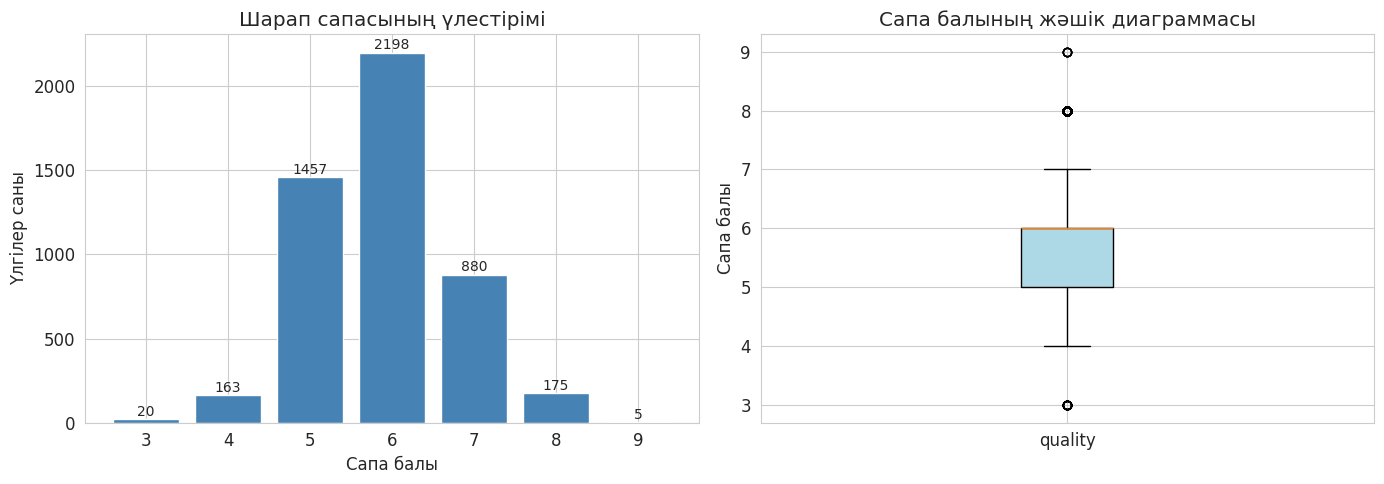

Сапа бойынша орташа мән: 5.88
Сапа бойынша медиана: 6.00


In [12]:
# Нысаналы айнымалының (quality) үлестірімін зерттеу
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Шарап сапасының үлестірімі')
axes[0].set_xlabel('Сапа балы')
axes[0].set_ylabel('Үлгілер саны')
axes[0].set_xticks(quality_counts.index)

for i, (idx, val) in enumerate(quality_counts.items()):
    axes[0].text(idx, val + 20, str(val), ha='center', fontsize=10)

# Жәшік диаграмма (boxplot)
axes[1].boxplot(df['quality'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'))
axes[1].set_title('Сапа балының жәшік диаграммасы')
axes[1].set_ylabel('Сапа балы')
axes[1].set_xticklabels(['quality'])

plt.tight_layout()
plt.savefig('quality_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Сапа бойынша орташа мән: {df["quality"].mean():.2f}')
print(f'Сапа бойынша медиана: {df["quality"].median():.2f}')

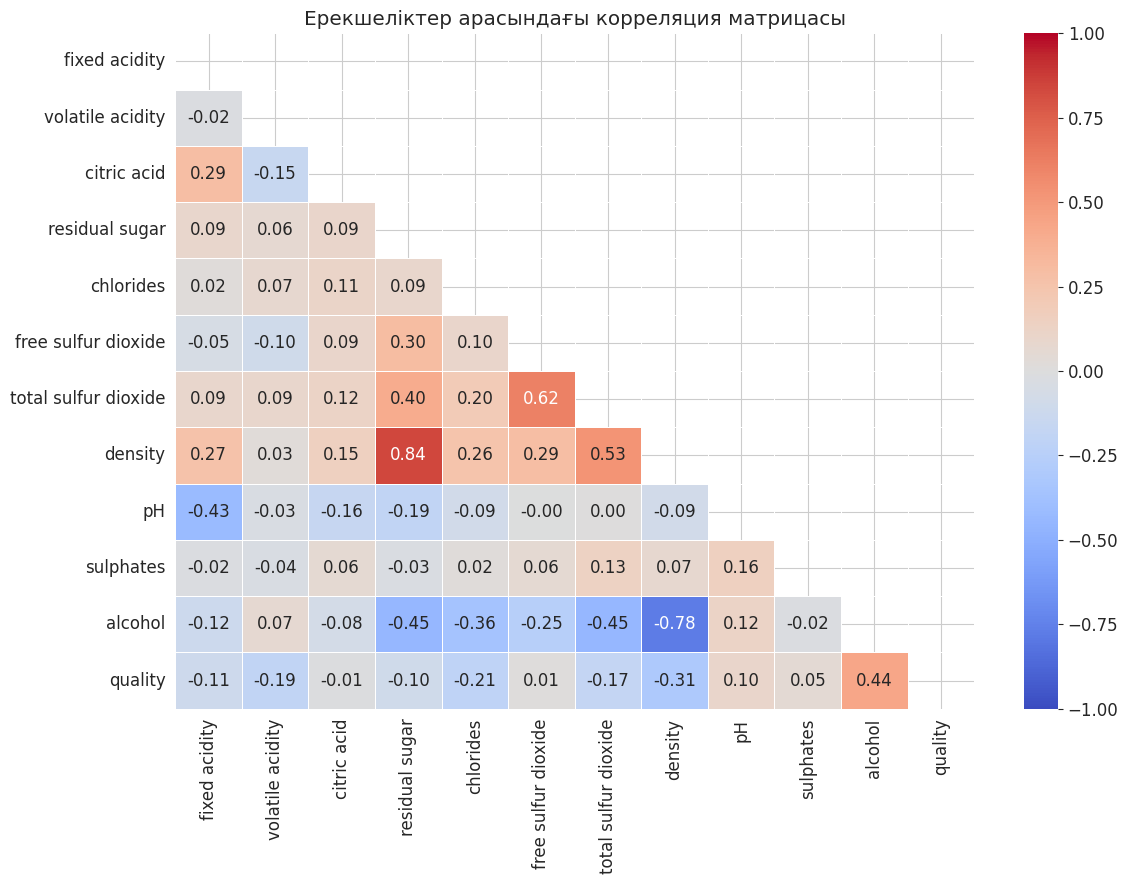

In [13]:
# Ерекшеліктер арасындағы корреляцияны зерттеу
plt.figure(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='coolwarm',
    center=0, vmin=-1, vmax=1,
    linewidths=0.5, mask=mask
)
plt.title('Ерекшеліктер арасындағы корреляция матрицасы')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
# Quality-мен ең жоғары корреляциясы бар ерекшеліктерді табу
quality_corr = df.corr()['quality'].drop('quality').abs().sort_values(ascending=False)
print('Quality-мен корреляция (абсолют мән бойынша сорттаған):')
print(quality_corr.round(3).to_string())

Quality-мен корреляция (абсолют мән бойынша сорттаған):
alcohol                 0.436
density                 0.307
chlorides               0.210
volatile acidity        0.195
total sulfur dioxide    0.175
fixed acidity           0.114
pH                      0.099
residual sugar          0.098
sulphates               0.054
citric acid             0.009
free sulfur dioxide     0.008


### Тапсырма 2.1

Корреляция матрицасын талдап, төмендегі сұрақтарға жауап беріңіз:

In [28]:
# Тапсырма 2.1: Корреляция талдауы

# TODO: quality-мен ең күшті оң корреляциясы бар ерекшелікті табыңыз
best_positive = quality_corr.idxmax()
print(f'Ең күшті оң корреляция: {best_positive}')

# TODO: quality-мен ең күшті теріс корреляциясы бар ерекшелікті табыңыз
best_negative = quality_corr.idxmin()
print(f'Ең күшті теріс корреляция: {best_negative}')

# TODO: density және alcohol арасындағы корреляция мәнін шығарыңыз
dens_alc_corr = df['density'].corr(df['alcohol'])
print(f'density-alcohol корреляциясы: {dens_alc_corr:.3f}')

Ең күшті оң корреляция: alcohol
Ең күшті теріс корреляция: free sulfur dioxide
density-alcohol корреляциясы: -0.780


> **Кеңес:** `df.corr()['quality']` — бұл quality бағанымен барлық ерекшеліктердің корреляция мәндерін береді. `.idxmax()` және `.idxmin()` әдістері ең жоғары және ең төмен мәннің индексін (ерекшелік атын) қайтарады.

Зерттелетін ерекшеліктер: ['alcohol', 'density', 'chlorides']


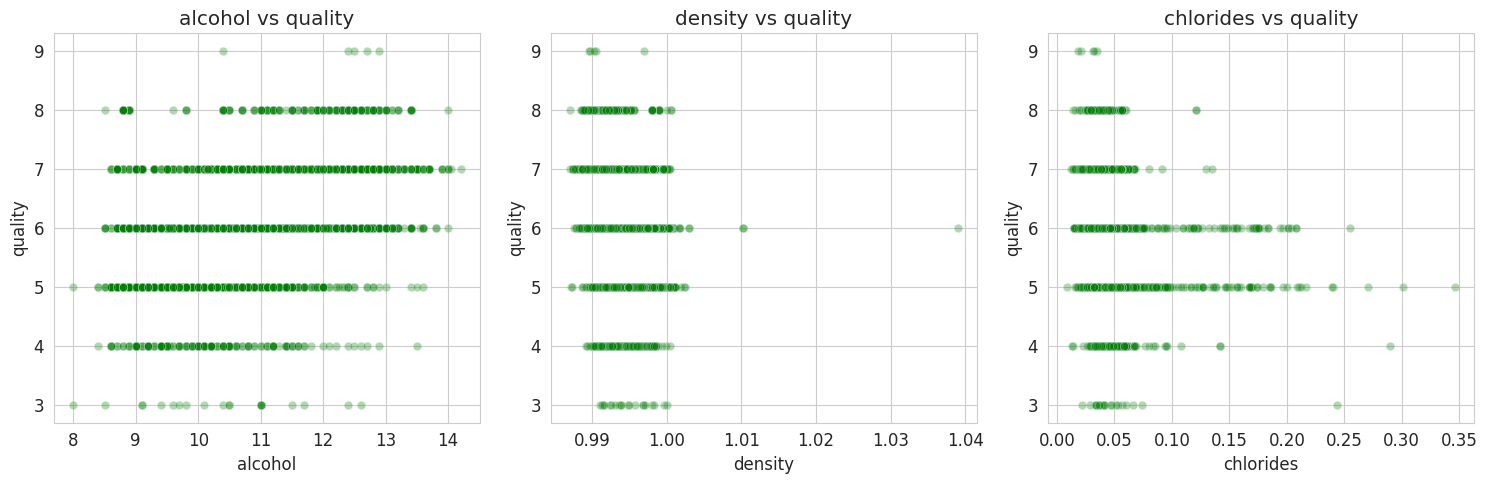

In [32]:
# Тапсырма 2.2: Жоғарғы 3 ерекшелік үшін scatter plot сызыңыз
top_features = quality_corr.head(3).index.tolist()
print(f'Зерттелетін ерекшеліктер: {top_features}')

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, feat in enumerate(top_features):
    # TODO: axes[i] үшін scatter plot сызыңыз (x=feat, y='quality')
    # Кеңес: axes[i].scatter(df[feat], df['quality'], alpha=0.3, ...)
    # TODO
    axes[i].scatter(df[feat], df['quality'], alpha=0.3, color='green', edgecolor='lavender', linewidth=0.5)
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('quality')
    axes[i].set_title(f'{feat} vs quality')

plt.tight_layout()
plt.show()



## 3-бөлім. Деректерді алдын ала өңдеу

**Мақсат:** Нейрондық желіге беруге дайын деректер жасау: класс белгілерін кодтау, деректерді бөлу және нормалау.

In [33]:
# Деректерді классификация үшін дайындау
# Сапа балдарын 3 класқа бөлу:
#   0 — төмен  (quality <= 5)
#   1 — орташа (quality == 6)
#   2 — жоғары (quality >= 7)

def encode_quality(q):
    if q <= 5:
        return 0
    elif q == 6:
        return 1
    else:
        return 2

df['quality_class'] = df['quality'].apply(encode_quality)

print('Класс үлестірімі:')
class_counts = df['quality_class'].value_counts().sort_index()
class_names = {0: 'Төмен (<=5)', 1: 'Орташа (6)', 2: 'Жоғары (>=7)'}
for cls, count in class_counts.items():
    pct = count / len(df) * 100
    print(f'  Класс {cls} [{class_names[cls]}]: {count} үлгі ({pct:.1f}%)')

Класс үлестірімі:
  Класс 0 [Төмен (<=5)]: 1640 үлгі (33.5%)
  Класс 1 [Орташа (6)]: 2198 үлгі (44.9%)
  Класс 2 [Жоғары (>=7)]: 1060 үлгі (21.6%)


In [34]:
# Ерекшеліктер мен нысаналы айнымалыны ажырату
feature_cols = [col for col in df.columns if col not in ['quality', 'quality_class']]
print(f'Ерекшеліктер саны: {len(feature_cols)}')
print(f'Ерекшеліктер: {feature_cols}')

X = df[feature_cols].values   # numpy массиві
y = df['quality_class'].values

print(f'\nX өлшемі: {X.shape}')
print(f'y өлшемі: {y.shape}')

Ерекшеліктер саны: 11
Ерекшеліктер: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

X өлшемі: (4898, 11)
y өлшемі: (4898,)


In [35]:
# Деректерді үйрету, валидация және тест жиындарына бөлу
# Бірінші бөліну: train+val / test = 80% / 20%
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Екінші бөліну: train / val = 75% / 25% (train+val ішінде)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
)

print('Деректер бөлінуі:')
print(f'  Үйрету жиыны : {X_train.shape[0]} үлгі ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'  Валидация жиыны: {X_val.shape[0]} үлгі ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'  Тест жиыны    : {X_test.shape[0]} үлгі ({X_test.shape[0]/len(X)*100:.1f}%)')

Деректер бөлінуі:
  Үйрету жиыны : 2938 үлгі (60.0%)
  Валидация жиыны: 980 үлгі (20.0%)
  Тест жиыны    : 980 үлгі (20.0%)


> **Маңызды:** `stratify=y` параметрі деректерді бөлген кезде класс үлестірімін сақтайды. Бұл әсіресе теңсіз деректер жиындарында өте маңызды.

In [36]:
# Ерекшеліктерді нормалау (StandardScaler)
# МАҢЫЗДЫ: Scaler тек train деректерінде үйретіледі!
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform
X_val_scaled   = scaler.transform(X_val)         # тек transform
X_test_scaled  = scaler.transform(X_test)        # тек transform

print('Нормалаудан кейін:')
print(f'X_train орташа мәне (баған бойынша): {X_train_scaled.mean(axis=0).round(4)}')
print(f'X_train стандартты ауытқу          : {X_train_scaled.std(axis=0).round(4)}')

Нормалаудан кейін:
X_train орташа мәне (баған бойынша): [ 0.  0. -0.  0. -0.  0. -0.  0. -0. -0. -0.]
X_train стандартты ауытқу          : [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Тапсырма 3.1

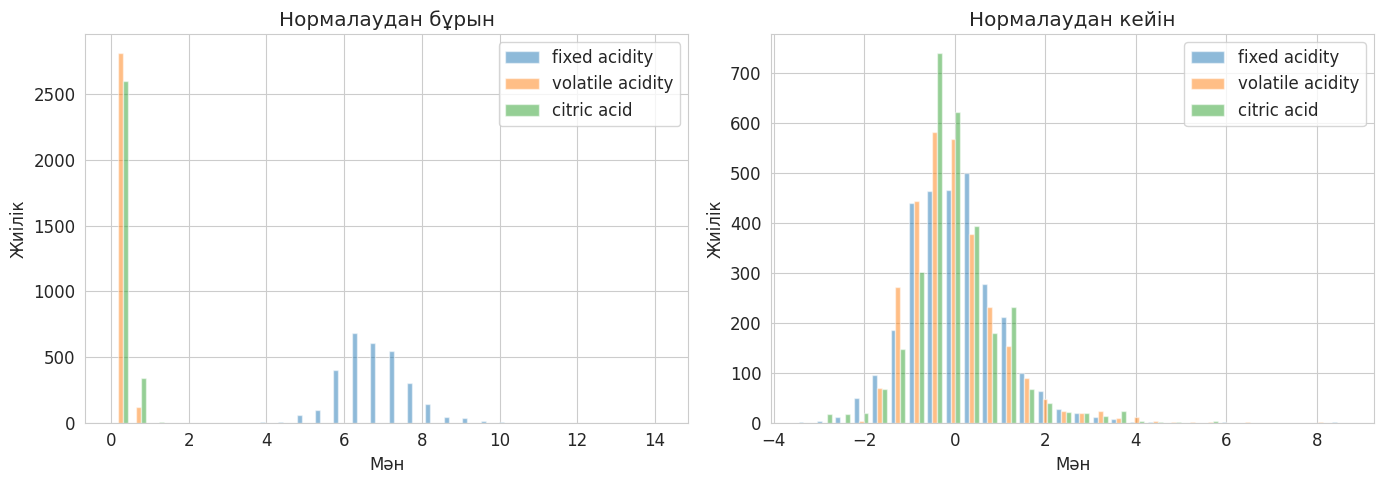

In [39]:
# Тапсырма 3.1: Нормалаудың маңыздылығын дәлелдеу
# Нормалаудан бұрын және кейінгі деректерді салыстырыңыз

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: Нормалаудан БҰРЫН алғашқы 3 ерекшеліктің гистограммасын сызыңыз
# axes[0] ішінде 3 ерекшелік гистограммасын қабаттастырып сызыңыз
# TODO
axes[0].hist(X_train[:, :3], bins=30, alpha=0.5, label=feature_cols[:3])
axes[0].set_title('Нормалаудан бұрын')
axes[0].set_xlabel('Мән')
axes[0].set_ylabel('Жиілік')
axes[0].legend(feature_cols[:3])

# TODO: Нормалаудан КЕЙІН сол ерекшеліктерді сызыңыз
# TODO
axes[1].hist(X_train_scaled[:, :3], bins=30, alpha=0.5, label=feature_cols[:3])
axes[1].set_title('Нормалаудан кейін')
axes[1].set_xlabel('Мән')
axes[1].set_ylabel('Жиілік')
axes[1].legend(feature_cols[:3])

plt.tight_layout()
plt.show()

### Тапсырма 3.2

Неліктен scaler тек үйрету деректерінде (`fit_transform`) үйретіліп, валидация мен тест деректерінде тек (`transform`) қолданылады? Жауабыңызды осы ұяшықта түсіндіріңіз.

**Жауап:**  
*(осында жазыңыз)*



## 4-бөлім. PyTorch Dataset және DataLoader

**Мақсат:** PyTorch-тың `Dataset` және `DataLoader` классын пайдаланып, деректерді модельге беруге арналған конвейер құру.

In [41]:
# Арнайы Dataset класын анықтау
class WineDataset(Dataset):
    """
    Шарап сапасы деректері үшін PyTorch Dataset класы.

    Args:
        X (np.ndarray): Ерекшеліктер матрицасы
        y (np.ndarray): Класс белгілері
    """

    def __init__(self, X, y):
        # numpy массивтерін PyTorch тензорларына айналдыру
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)   # LongTensor — CrossEntropyLoss үшін қажет

    def __len__(self):
        """Dataset-тегі үлгілер санын қайтарады."""
        return len(self.y)

    def __getitem__(self, idx):
        """idx индексіндегі үлгіні қайтарады."""
        return self.X[idx], self.y[idx]


# Dataset объектілерін жасау
train_dataset = WineDataset(X_train_scaled, y_train)
val_dataset   = WineDataset(X_val_scaled,   y_val)
test_dataset  = WineDataset(X_test_scaled,  y_test)

print(f'Үйрету Dataset өлшемі : {len(train_dataset)}')
print(f'Валидация Dataset өлшемі: {len(val_dataset)}')
print(f'Тест Dataset өлшемі  : {len(test_dataset)}')

# Бір үлгіні тексеру
sample_X, sample_y = train_dataset[0]
print(f'\nБір үлгінің ерекшелік тензоры: {sample_X}')
print(f'Бір үлгінің класс белгісі: {sample_y}')

Үйрету Dataset өлшемі : 2938
Валидация Dataset өлшемі: 980
Тест Dataset өлшемі  : 980

Бір үлгінің ерекшелік тензоры: tensor([-1.4826, -0.8659, -0.5493, -1.0981, -0.2591,  0.9593, -0.8241, -1.2957,
         2.0439, -0.8829,  0.5824])
Бір үлгінің класс белгісі: 0


In [42]:
# DataLoader объектілерін жасау
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,         # Үйрету кезінде деректерді aralas
    drop_last=False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False         # Валидация кезінде аралас болмайды
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f'Batch өлшемі: {BATCH_SIZE}')
print(f'Үйрету batchtер саны: {len(train_loader)}')
print(f'Валидация batchtер саны: {len(val_loader)}')

# Бір batch-ті тексеру
for batch_X, batch_y in train_loader:
    print(f'\nБір batch:')
    print(f'  X batch өлшемі: {batch_X.shape}')
    print(f'  y batch өлшемі: {batch_y.shape}')
    break

Batch өлшемі: 64
Үйрету batchtер саны: 46
Валидация batchtер саны: 16

Бір batch:
  X batch өлшемі: torch.Size([64, 11])
  y batch өлшемі: torch.Size([64])


### Тапсырма 4.1

In [ ]:
# Тапсырма 4.1: Dataset класын кеңейтіңіз
# Деректердің статистикасын қайтаратын get_stats() әдісін қосыңыз

class WineDatasetExtended(Dataset):

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

    def get_stats(self):
        """
        TODO: Ерекшеліктердің орташа мәні мен стандартты ауытқуын сөздік
        (dictionary) ретінде қайтаратын әдіс жазыңыз.
        Қайтарылатын формат: {'mean': tensor, 'std': tensor}
        """
        # TODO
        mean = self.X.mean(dim=0)
        std = self.X.std(dim=0)
        return {'mean': mean, 'std': std}

    def class_distribution(self):
        """
        TODO: Әр класстың үлгілер санын сөздік ретінде қайтарыңыз.
        Формат: {class_id: count}
        """
       return pass


# Тексеру
ext_dataset = WineDatasetExtended(X_train_scaled, y_train)
stats = ext_dataset.get_stats()
dist  = ext_dataset.class_distribution()
print('Статистика:', stats)
print('Класс үлестірімі:', dist)

Статистика: {'mean': tensor([-6.4920e-10,  0.0000e+00,  6.4920e-10,  6.4920e-10, -3.2460e-09,
        -1.0387e-08,  1.9476e-09, -6.1674e-09,  8.4396e-09, -6.4920e-10,
         6.4920e-10]), 'std': tensor([1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002, 1.0002,
        1.0002, 1.0002])}
Класс үлестірімі: {0: 984, 1: 1318, 2: 636}


> **Кеңес:** `self.X.mean(dim=0)` барлық үлгілер бойынша (жол бойынша) орташа мән береді — нәтиже ерекшелік санына тең тензор. `torch.unique(self.y, return_counts=True)` бірегей мәндер мен олардың санын береді.



## 5-бөлім. Нейрондық желіні құру

**Мақсат:** `nn.Module` класын мұрагер ету арқылы толық байланысқан нейрондық желі архитектурасын жасау және оны бірнеше нұсқада салыстыру.

In [ ]:
# Негізгі нейрондық желі класы
class WineClassifier(nn.Module):
    """
    Шарап сапасын классификациялауға арналған толық байланысқан нейрондық желі.

    Архитектура:
        Input(11) -> FC(64) -> ReLU -> Dropout(0.3)
                 -> FC(32) -> ReLU -> Dropout(0.3)
                 -> FC(3)  -> (softmax жоғалту функциясында қолданылады)

    Args:
        input_dim  (int): Кіріс ерекшеліктер саны
        hidden1    (int): Бірінші жасырын қабат нейрондары
        hidden2    (int): Екінші жасырын қабат нейрондары
        num_classes(int): Класс саны
        dropout_p  (float): Dropout ықтималдығы
    """

    def __init__(self, input_dim=11, hidden1=64, hidden2=32,
                 num_classes=3, dropout_p=0.3):
        super(WineClassifier, self).__init__()

        self.network = nn.Sequential(
            # Бірінші жасырын қабат
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            # Екінші жасырын қабат
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            # Шығыс қабат
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        """Алға тарату (forward pass)."""
        return self.network(x)


# Модельді жасау
INPUT_DIM   = X_train_scaled.shape[1]  # 11 ерекшелік
NUM_CLASSES = 3

model = WineClassifier(
    input_dim=INPUT_DIM,
    hidden1=64,
    hidden2=32,
    num_classes=NUM_CLASSES,
    dropout_p=0.3
).to(device)

print('Модель архитектурасы:')
print(model)
print(f'\nЖалпы параметрлер саны: {sum(p.numel() for p in model.parameters()):,}')
print(f'Үйренетін параметрлер: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

In [ ]:
# Модельдің алға тарату жұмысын тексеру
model.eval()
with torch.no_grad():
    dummy_input = torch.randn(4, INPUT_DIM).to(device)  # 4 үлгі
    dummy_output = model(dummy_input)
    print(f'Сынамалы кіріс өлшемі : {dummy_input.shape}')
    print(f'Сынамалы шығыс өлшемі: {dummy_output.shape}')
    print(f'Шығыс (логиттер):\n{dummy_output}')

### Тапсырма 5.1

In [ ]:
# Тапсырма 5.1: Тереңірек нейрондық желі құрыңыз
# 3 жасырын қабаты бар моделі жасаңыз: 128 -> 64 -> 32 -> 3
# BatchNorm1d және ReLU активациясын қосыңыз
# dropout_p параметрін конструкторда реттелетін етіп жасаңыз

class DeepWineClassifier(nn.Module):
    """
    TODO: 3 жасырын қабаты бар нейрондық желі класын толтырыңыз.
    """

    def __init__(self, input_dim=11, num_classes=3, dropout_p=0.3):
        super(DeepWineClassifier, self).__init__()

        # TODO: self.network анықтаңыз
        # Қабаттар: Linear(11->128) -> BN -> ReLU -> Dropout
        #           Linear(128->64) -> BN -> ReLU -> Dropout
        #           Linear(64->32)  -> BN -> ReLU -> Dropout
        #           Linear(32->3)
        self.network = # TODO

    def forward(self, x):
        # TODO
        pass


# Тексеру
deep_model = DeepWineClassifier(input_dim=INPUT_DIM, num_classes=NUM_CLASSES).to(device)
deep_model.eval()
with torch.no_grad():
    test_out = deep_model(torch.randn(4, INPUT_DIM).to(device))
print(f'DeepModel шығыс өлшемі: {test_out.shape}')  # [4, 3] болуы тиіс
print(f'Жалпы параметрлер: {sum(p.numel() for p in deep_model.parameters()):,}')

### Тапсырма 5.2

In [ ]:
# Тапсырма 5.2: Активация функциялары
# ReLU, Sigmoid, Tanh және Leaky ReLU функцияларын визуализациялаңыз

x_range = torch.linspace(-4, 4, 200)

activations = {
    'ReLU': nn.ReLU(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh(),
    'LeakyReLU': nn.LeakyReLU(0.1)
}

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, (name, func) in enumerate(activations.items()):
    y_vals = func(x_range).detach().numpy()
    # TODO: axes[i] үшін сызықтық графикті сызыңыз (x_range vs y_vals)
    # x=0 және y=0 арқылы өтетін тік және көлденең сызықтар қосыңыз (axhline, axvline)
    # TODO
    axes[i].set_title(f'{name} активация функциясы')
    axes[i].set_xlabel('x')
    axes[i].set_ylabel('f(x)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

> **Кеңес:** `axes[i].axhline(0, color='k', linewidth=0.8)` — y=0 бойынша көлденең сызық. `axes[i].axvline(0, color='k', linewidth=0.8)` — x=0 бойынша тік сызық.



## 6-бөлім. Жоғалту функциясы және оптимизатор

**Мақсат:** Классификация үшін CrossEntropyLoss жоғалту функциясын және Adam оптимизаторын баптап, олардың рөлін түсіну.

In [ ]:
# Жоғалту функциясы — CrossEntropyLoss
# CrossEntropyLoss = LogSoftmax + NLLLoss
# Ескерту: CrossEntropyLoss кірісте LogSoftmax-ты өзі есептейді,
#          сондықтан модельдің соңғы қабатына Softmax қосудың қажеті жоқ

criterion = nn.CrossEntropyLoss()

# Оптимизатор — Adam
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4   # L2 регуляризация

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

print('Жоғалту функциясы:', criterion)
print('Оптимизатор:', optimizer)
print(f'Оқыту жылдамдығы: {LEARNING_RATE}')
print(f'Weight decay (L2): {WEIGHT_DECAY}')

In [ ]:
# CrossEntropyLoss жұмысын түсіну
# Қарапайым мысал: 3 класс, 4 үлгі

print('--- CrossEntropyLoss мысалы ---')
logits_example = torch.tensor([
    [2.0, 0.5, 0.1],   # Модель 0-ші класты болжайды
    [0.1, 3.0, 0.2],   # Модель 1-ші класты болжайды
    [0.5, 0.2, 4.0],   # Модель 2-ші класты болжайды
    [1.0, 1.0, 1.0],   # Модель сенімсіз (бірдей)
])
labels_example = torch.tensor([0, 1, 2, 0])  # Нақты класс белгілері

loss_val = criterion(logits_example, labels_example)
print(f'Жоғалту мәні: {loss_val.item():.4f}')

# Болжалды ықтималдықтар (Softmax арқылы)
probs = torch.softmax(logits_example, dim=1)
print('\nБолжалды ықтималдықтар:')
for i, (p, l) in enumerate(zip(probs, labels_example)):
    predicted = p.argmax().item()
    correct = '(дурыс)' if predicted == l.item() else '(қате)'
    print(f'  Үлгі {i}: {p.detach().numpy().round(3)} -> болжам={predicted}, нақты={l.item()} {correct}')

In [ ]:
# Learning Rate Scheduler — оқыту барысында lr-ды автоматты азайту
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # Жоғалту азайған кезде
    factor=0.5,       # lr-ды 2 есе азайт
    patience=10,      # 10 epoch жақсармаса
    min_lr=1e-6,      # Минималды мән
    verbose=True
)

print('Learning Rate Scheduler бапталды: ReduceLROnPlateau')

### Тапсырма 6.1

In [ ]:
# Тапсырма 6.1: Оптимизаторларды салыстыру
# SGD, Adam, RMSprop оптимизаторларын жасаңыз және параметрлерін шығарыңыз

# TODO: SGD оптимизатор жасаңыз (momentum=0.9, lr=0.01)
optimizer_sgd = # TODO

# TODO: RMSprop оптимизатор жасаңыз (lr=0.001, alpha=0.99)
optimizer_rms = # TODO

# Параметрлерді шығару
optimizers = {
    'Adam': optimizer,
    'SGD': optimizer_sgd,
    'RMSprop': optimizer_rms
}

for name, opt in optimizers.items():
    lr = opt.param_groups[0]['lr']
    print(f'{name}: lr={lr}')

> **Кеңес:** `optim.SGD(model.parameters(), lr=0.01, momentum=0.9)` — SGD оптимизатор. `optim.RMSprop(model.parameters(), lr=0.001, alpha=0.99)` — RMSprop.


## 7-бөлім. Үйрету циклі

**Мақсат:** PyTorch-та классикалық үйрету циклін (training loop) жазу: алға тарату, жоғалту есептеу, артқа тарату (backpropagation) және параметрлерді жаңарту.

In [ ]:
# Бір epoch үшін үйрету функциясы
def train_one_epoch(model, loader, criterion, optimizer, device):
    """
    Бір epoch бойы модельді үйретеді.

    Returns:
        avg_loss (float): Орташа жоғалту мәні
        accuracy (float): Дәлдік (%)
    """
    model.train()   # Үйрету режимі (Dropout, BatchNorm белсенді)

    total_loss    = 0.0
    correct_count = 0
    total_count   = 0

    for batch_X, batch_y in loader:
        # Деректерді құрылғыға жіберу
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        # 1. Градиенттерді нөлдеу (маңызды!)
        optimizer.zero_grad()

        # 2. Алға тарату (forward pass)
        outputs = model(batch_X)           # Логиттер: [batch, num_classes]

        # 3. Жоғалту есептеу
        loss = criterion(outputs, batch_y)

        # 4. Артқа тарату (backward pass)
        loss.backward()

        # 5. Gradient clipping (тұрақсыздықтың алдын алу)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # 6. Параметрлерді жаңарту
        optimizer.step()

        # Статистика
        total_loss += loss.item() * batch_X.size(0)
        _, predicted = outputs.max(dim=1)
        correct_count += (predicted == batch_y).sum().item()
        total_count   += batch_X.size(0)

    avg_loss = total_loss / total_count
    accuracy = correct_count / total_count * 100
    return avg_loss, accuracy


# Бағалау функциясы
def evaluate(model, loader, criterion, device):
    """
    Модельді бағалайды (градиентсіз).

    Returns:
        avg_loss (float): Орташа жоғалту
        accuracy (float): Дәлдік (%)
    """
    model.eval()   # Бағалау режимі (Dropout, BatchNorm өшіріледі)

    total_loss    = 0.0
    correct_count = 0
    total_count   = 0

    with torch.no_grad():  # Градиент есептелмейді
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            outputs = model(batch_X)
            loss    = criterion(outputs, batch_y)

            total_loss += loss.item() * batch_X.size(0)
            _, predicted = outputs.max(dim=1)
            correct_count += (predicted == batch_y).sum().item()
            total_count   += batch_X.size(0)

    avg_loss = total_loss / total_count
    accuracy = correct_count / total_count * 100
    return avg_loss, accuracy

print('Үйрету және бағалау функциялары дайын.')

In [ ]:
# Толық үйрету циклі
NUM_EPOCHS    = 100
PATIENCE      = 20    # Early stopping: 20 epoch жақсармаса тоқтату

# Тарих сақтау
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc' : [], 'val_acc' : [],
    'lr'        : []
}

# Early stopping үшін айнымалылар
best_val_loss   = float('inf')
best_model_state = None
patience_counter = 0

print(f'Үйрету басталды: {NUM_EPOCHS} epoch, PATIENCE={PATIENCE}')
print('-' * 70)
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Val Loss":>10} | {"Train Acc":>10} | {"Val Acc":>10}')
print('-' * 70)

for epoch in range(1, NUM_EPOCHS + 1):

    # Үйрету
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # Валидация
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    # Scheduler жаңарту
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Тарихты сақтау
    history['train_loss'].append(train_loss)
    history['val_loss'  ].append(val_loss)
    history['train_acc' ].append(train_acc)
    history['val_acc'   ].append(val_acc)
    history['lr'        ].append(current_lr)

    # Ең жақсы модельді сақтау
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        patience_counter = 0
        marker = ' *'
    else:
        patience_counter += 1
        marker = ''

    # Логгинг (әр 10 epoch)
    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6} | {train_loss:>10.4f} | {val_loss:>10.4f} | '
              f'{train_acc:>9.2f}% | {val_acc:>9.2f}%{marker}')

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping: {epoch}-ші epoch-та тоқтатылды.')
        break

print('-' * 70)
print(f'Ең жақсы валидация жоғалтуы: {best_val_loss:.4f}')

# Ең жақсы модель күйін қалпына келтіру
model.load_state_dict(best_model_state)
print('Ең жақсы модель күйі қалпына келтірілді.')

### Тапсырма 7.1

In [ ]:
# Тапсырма 7.1: Үйрету тарихын визуализациялау
# Loss және Accuracy қисықтарын сызыңыз

epochs_range = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# TODO: axes[0] — Train Loss және Val Loss қисықтарын сызыңыз
# Екі қисықты бір суретте: train_loss (синий) және val_loss (кызыл)
# TODO
axes[0].set_title('Жоғалту қисықтары')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# TODO: axes[1] — Train Accuracy және Val Accuracy қисықтарын сызыңыз
# TODO
axes[1].set_title('Дәлдік қисықтары')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()

# TODO: axes[2] — Learning Rate өзгерісін сызыңыз
# TODO
axes[2].set_title('Оқыту жылдамдығы (LR)')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig('training_history.png', dpi=120, bbox_inches='tight')
plt.show()

### Тапсырма 7.2: Үйрету циклін түсіну

Үйрету функциясындағы мына қадамдарды өз сөзіңізбен түсіндіріңіз:

1. `optimizer.zero_grad()` — неліктен бұл бірінші орындалады?
2. `loss.backward()` — бұл нені есептейді?
3. `torch.nn.utils.clip_grad_norm_()` — бұл неге қажет?
4. `model.eval()` / `model.train()` — бұл екеуінің айырмашылығы?
5. `torch.no_grad()` — бұл не үшін қолданылады?

**Жауаптарыңыз:**  
*(осында жазыңыз)*



## 8-бөлім. Бағалау және нәтижелерді талдау

**Мақсат:** Модельді тест жиынында бағалап, шатасу матрицасы мен классификация есебі арқылы нәтижелерді егжей-тегжейлі талдау.

In [ ]:
# Тест жиынындағы болжамдарды жинау
def get_predictions(model, loader, device):
    """
    Барлық болжамдар мен нақты белгілерді жинайды.

    Returns:
        all_preds  (np.array): Болжалды класс белгілері
        all_labels (np.array): Нақты класс белгілері
        all_probs  (np.array): Болжалды ықтималдықтар
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch_X, batch_y in loader:
            batch_X = batch_X.to(device)
            outputs = model(batch_X)
            probs   = torch.softmax(outputs, dim=1)
            _, preds = outputs.max(dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch_y.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


# Тест болжамдарын алу
test_preds, test_labels, test_probs = get_predictions(model, test_loader, device)

test_acc = (test_preds == test_labels).mean() * 100
print(f'Тест жиынындағы дәлдік: {test_acc:.2f}%')

In [ ]:
# Классификация есебі (precision, recall, F1)
class_labels = ['Төмен (0)', 'Орташа (1)', 'Жоғары (2)']
print('Классификация есебі:')
print(classification_report(test_labels, test_preds, target_names=class_labels))

In [ ]:
# Шатасу матрицасын визуализациялау
cm = confusion_matrix(test_labels, test_preds)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Нормаланған

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Сандық шатасу матрицасы
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=class_labels, yticklabels=class_labels,
    ax=axes[0]
)
axes[0].set_title('Шатасу матрицасы (сандар)')
axes[0].set_xlabel('Болжалды класс')
axes[0].set_ylabel('Нақты класс')

# Нормаланған шатасу матрицасы
sns.heatmap(
    cm_normalized, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=class_labels, yticklabels=class_labels,
    vmin=0, vmax=1, ax=axes[1]
)
axes[1].set_title('Нормаланған шатасу матрицасы')
axes[1].set_xlabel('Болжалды класс')
axes[1].set_ylabel('Нақты класс')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

### Тапсырма 8.1

In [ ]:
# Тапсырма 8.1: Шатасу матрицасын талдаңыз
# Қандай класта модель ең жақсы/нашар жұмыс істейді?

# TODO: Әр класс үшін precision, recall, F1 мәндерін қолмен есептеңіз
# Шатасу матрицасын (cm) пайдаланыңыз

for cls_idx in range(3):
    tp = cm[cls_idx, cls_idx]
    fp = # TODO: False Positive есептеңіз
    fn = # TODO: False Negative есептеңіз

    precision = # TODO: Precision = TP / (TP + FP)
    recall    = # TODO: Recall    = TP / (TP + FN)
    f1        = # TODO: F1        = 2 * Precision * Recall / (Precision + Recall)

    print(f'Класс {cls_idx} [{class_labels[cls_idx]}]:')
    print(f'  TP={tp}, FP={fp}, FN={fn}')
    print(f'  Precision={precision:.3f}, Recall={recall:.3f}, F1={f1:.3f}')

> **Кеңес:** `cm` матрицасында `cm[i, j]` — нақты класс i, болжалды класс j дегенді білдіреді. Precision үшін баған суммасын, Recall үшін жол суммасын қолданыңыз.

In [ ]:
# Болжалды ықтималдықтарды визуализациялау
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for cls_idx in range(3):
    # Нақты осы класқа жататын үлгілерді алу
    mask = (test_labels == cls_idx)
    probs_for_class = test_probs[mask, cls_idx]  # P(class=cls_idx | x)

    axes[cls_idx].hist(probs_for_class, bins=20, color='steelblue',
                       edgecolor='white', range=(0, 1))
    axes[cls_idx].set_title(f'Класс {cls_idx} болжалды ықтималдықтары')
    axes[cls_idx].set_xlabel('Ықтималдық')
    axes[cls_idx].set_ylabel('Жиілік')
    axes[cls_idx].axvline(0.5, color='red', linestyle='--', label='Шек=0.5')
    axes[cls_idx].legend()

plt.suptitle('Нақты класс үлгілері үшін болжалды ықтималдықтар', fontsize=13)
plt.tight_layout()
plt.show()

### Тапсырма 8.2

In [ ]:
# Тапсырма 8.2: Модель ең қиын деп санайтын үлгілерді табыңыз
# Болжалды максималды ықтималдығы ең төмен 10 үлгіні шығарыңыз

# TODO: Максималды ықтималдықты есептеңіз (әр үлгі үшін)
max_probs = # TODO

# TODO: Ең төменгі 10 max_prob-тың индекстерін табыңыз
uncertain_indices = # TODO

print('Модель ең сенімсіз болжаған 10 үлгі:')
print(f'{"Индекс":>8} | {"Нақты":>10} | {"Болжам":>10} | {"Макс. ықт.":>12}')
print('-' * 50)
for idx in uncertain_indices:
    true_cls = test_labels[idx]
    pred_cls = test_preds[idx]
    max_p    = max_probs[idx]
    print(f'{idx:>8} | {class_labels[true_cls]:>10} | {class_labels[pred_cls]:>10} | {max_p:>12.4f}')


## 9-бөлім. Гиперпараметрлермен тәжірибе

**Мақсат:** Batch size, learning rate, hidden layer өлшемі және Dropout сияқты гиперпараметрлердің модель нәтижесіне әсерін зерттеу.

In [ ]:
# Жалпы үйрету функциясы (қысқартылған нұсқа — тәжірибелер үшін)
def train_model(config, train_loader, val_loader, device, verbose=False):
    """
    Конфигурация сөздігі бойынша модельді үйретеді.

    Args:
        config (dict): lr, hidden1, hidden2, dropout_p, epochs кілттері

    Returns:
        best_val_acc (float): Ең жақсы валидация дәлдігі
        history      (dict) : Тарих
    """
    model_exp = WineClassifier(
        input_dim  = INPUT_DIM,
        hidden1    = config.get('hidden1', 64),
        hidden2    = config.get('hidden2', 32),
        num_classes= NUM_CLASSES,
        dropout_p  = config.get('dropout_p', 0.3)
    ).to(device)

    crit = nn.CrossEntropyLoss()
    opt  = optim.Adam(model_exp.parameters(),
                      lr=config.get('lr', 1e-3),
                      weight_decay=1e-4)

    best_val_acc   = 0.0
    hist_train_acc = []
    hist_val_acc   = []

    for epoch in range(1, config.get('epochs', 60) + 1):
        _, tr_acc = train_one_epoch(model_exp, train_loader, crit, opt, device)
        _, vl_acc = evaluate(model_exp, val_loader, crit, device)
        hist_train_acc.append(tr_acc)
        hist_val_acc.append(vl_acc)
        if vl_acc > best_val_acc:
            best_val_acc = vl_acc

    if verbose:
        print(f"  Ең жақсы val acc: {best_val_acc:.2f}%")

    return best_val_acc, {'train_acc': hist_train_acc, 'val_acc': hist_val_acc}

print('Тәжірибе функциясы дайын.')

In [ ]:
# Learning Rate тәжірибесі
print('Learning Rate тәжірибесі:')
lr_values = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2]
lr_results = {}

for lr in lr_values:
    config = {'lr': lr, 'epochs': 60}
    best_acc, _ = train_model(config, train_loader, val_loader, device)
    lr_results[lr] = best_acc
    print(f'  lr={lr:.1e} -> Val Acc={best_acc:.2f}%')

best_lr = max(lr_results, key=lr_results.get)
print(f'\nЕң жақсы LR: {best_lr:.1e} -> {lr_results[best_lr]:.2f}%')

In [ ]:
# Learning rate нәтижелерін визуализациялау
fig, ax = plt.subplots(figsize=(9, 5))
lrs_str  = [f'{lr:.0e}' for lr in lr_results.keys()]
accs_val = list(lr_results.values())

bars = ax.bar(lrs_str, accs_val, color='steelblue', edgecolor='white')
for bar, val in zip(bars, accs_val):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10)

ax.set_title('Learning Rate vs Валидация дәлдігі')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Val Accuracy (%)')
ax.set_ylim(min(accs_val) - 5, 100)
plt.tight_layout()
plt.show()

### Тапсырма 9.1

In [ ]:
# Тапсырма 9.1: Dropout тәжірибесі
# Dropout мәнінің [0.0, 0.1, 0.3, 0.5, 0.7] диапазонында нәтижеге әсерін зерттеңіз

dropout_values = [0.0, 0.1, 0.3, 0.5, 0.7]
dropout_results = {}

print('Dropout тәжірибесі:')
for dp in dropout_values:
    # TODO: config сөздігін жасаңыз және train_model шақырыңыз
    config = # TODO
    best_acc, _ = # TODO
    dropout_results[dp] = best_acc
    print(f'  dropout={dp:.1f} -> Val Acc={best_acc:.2f}%')

# TODO: Нәтижелерді барлық диаграмма арқылы визуализациялаңыз
# TODO

### Тапсырма 9.2

In [ ]:
# Тапсырма 9.2: Batch size тәжірибесі
# Batch size-тың [16, 32, 64, 128, 256] нәтижеге әсерін зерттеңіз

batch_sizes = [16, 32, 64, 128, 256]
batch_results = {}

print('Batch Size тәжірибесі:')
for bs in batch_sizes:
    # TODO: Осы batch size үшін жаңа DataLoader жасаңыз
    temp_train_loader = # TODO
    temp_val_loader   = # TODO

    # TODO: Модельді үйретіп нәтижені сақтаңыз
    config = {'lr': best_lr, 'epochs': 60}
    best_acc, _ = # TODO
    batch_results[bs] = best_acc
    print(f'  batch_size={bs:>4} -> Val Acc={best_acc:.2f}%')

best_bs = max(batch_results, key=batch_results.get)
print(f'\nЕң жақсы Batch Size: {best_bs}')

> **Кеңес:** Batch size үлкейген сайын epoch уақыты азаяды, бірақ модель жалпыланғыштығы (generalization) нашарлауы мүмкін. Batch size кішірейген сайын нейрондық желі нашар оптимизациялануы мүмкін.

### Тапсырма 9.3

In [ ]:
# Тапсырма 9.3: Желі тереңдігімен тәжірибе
# 1, 2, 3, 4 жасырын қабатты нейрондық желілерді салыстырыңыз

class FlexibleClassifier(nn.Module):
    """
    TODO: n жасырын қабатты нейрондық желі.
    Конструктор hidden_sizes тізімін қабылдасын.
    Мысал: hidden_sizes=[64, 32] -> 2 жасырын қабат.
    """

    def __init__(self, input_dim, hidden_sizes, num_classes, dropout_p=0.3):
        super(FlexibleClassifier, self).__init__()

        # TODO: hidden_sizes тізімі бойынша автоматты қабаттар тізбегін жасаңыз
        layers = []
        in_size = input_dim

        for h_size in hidden_sizes:
            # TODO: Linear, BatchNorm1d, ReLU, Dropout қосыңыз
            # TODO
            in_size = h_size

        layers.append(nn.Linear(in_size, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# Тексеру
flex_model = FlexibleClassifier(INPUT_DIM, [128, 64, 32], NUM_CLASSES).to(device)
flex_model.eval()
with torch.no_grad():
    out = flex_model(torch.randn(4, INPUT_DIM).to(device))
print(f'FlexibleClassifier шығыс: {out.shape}')  # [4, 3] болуы тиіс
print(flex_model)

---

## 10-бөлім. Модельді сақтау және жүктеу

**Мақсат:** Үйретілген модельді дискке сақтап, оны кейін жүктеп болжам жасауды үйрену.

In [ ]:
# Модельді сақтаудың екі тәсілі

# 1-тәсіл: Тек state_dict (ұсынылатын тәсіл)
torch.save({
    'model_state_dict' : model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_loss'    : best_val_loss,
    'config': {
        'input_dim'  : INPUT_DIM,
        'hidden1'    : 64,
        'hidden2'    : 32,
        'num_classes': NUM_CLASSES,
        'dropout_p'  : 0.3
    }
}, 'wine_classifier_checkpoint.pth')

print('Модель сақталды: wine_classifier_checkpoint.pth')

# 2-тәсіл: Толық модель объектісі (тек сынамалық мақсатта)
torch.save(model, 'wine_classifier_full.pth')
print('Толық модель сақталды: wine_classifier_full.pth')

In [ ]:
# Модельді жүктеу (checkpoint)
checkpoint = torch.load('wine_classifier_checkpoint.pth', map_location=device)

# Жаңа модель объектісі жасау
config_loaded = checkpoint['config']
loaded_model  = WineClassifier(
    input_dim   = config_loaded['input_dim'],
    hidden1     = config_loaded['hidden1'],
    hidden2     = config_loaded['hidden2'],
    num_classes = config_loaded['num_classes'],
    dropout_p   = config_loaded['dropout_p']
).to(device)

# Параметрлерді жүктеу
loaded_model.load_state_dict(checkpoint['model_state_dict'])
loaded_model.eval()

print('Модель сәтті жүктелді.')
print(f'Ең жақсы val loss: {checkpoint["best_val_loss"]:.4f}')

# Жүктелген модельді тексеру
_, loaded_acc = evaluate(loaded_model, test_loader, criterion, device)
print(f'Жүктелген модельдің тест дәлдігі: {loaded_acc:.2f}%')

In [ ]:
# Жаңа үлгілер үшін болжам жасау (inference)
def predict_single(model, features, scaler, device):
    """
    Бір үлгі үшін болжам жасайды.

    Args:
        features (list/array): Нормаланбаған 11 ерекшелік

    Returns:
        pred_class (int)  : Болжалды класс
        probs      (array): Барлық класс ықтималдықтары
    """
    model.eval()
    features_arr    = np.array(features).reshape(1, -1)
    features_scaled = scaler.transform(features_arr)
    features_tensor = torch.FloatTensor(features_scaled).to(device)

    with torch.no_grad():
        output     = model(features_tensor)
        probs      = torch.softmax(output, dim=1).cpu().numpy()[0]
        pred_class = probs.argmax()

    return int(pred_class), probs


# Мысал: Тест жиынынан бірінші үлгімен болжам
sample_features = X_test[0]  # Нормаланбаған ерекшеліктер
sample_true     = y_test[0]

pred_cls, pred_probs = predict_single(loaded_model, sample_features, scaler, device)

print('Болжам нәтижесі:')
print(f'  Нақты класс   : {sample_true} [{class_labels[sample_true]}]')
print(f'  Болжалды класс: {pred_cls} [{class_labels[pred_cls]}]')
print(f'  Ықтималдықтар :')
for i, (p, name) in enumerate(zip(pred_probs, class_labels)):
    bar = '#' * int(p * 30)
    print(f'    {name}: {p:.4f} |{bar}')

### Тапсырма 10.1

In [ ]:
# Тапсырма 10.1: Модельді TorchScript-ке конвертациялаңыз
# TorchScript — модельді Python-сыз орындауға мүмкіндік береді

# TODO: torch.jit.script() арқылы модельді конвертациялаңыз
scripted_model = # TODO

# TODO: Конвертацияланған модельді 'wine_classifier_scripted.pt' файлына сақтаңыз
# TODO

# Тексеру
loaded_scripted = torch.jit.load('wine_classifier_scripted.pt', map_location=device)
loaded_scripted.eval()

with torch.no_grad():
    test_input  = torch.FloatTensor(X_test_scaled[:5]).to(device)
    script_out  = loaded_scripted(test_input)
    normal_out  = loaded_model(test_input)

print('TorchScript модель шығысы:')
print(script_out)
print('\nКәдімгі модель шығысы:')
print(normal_out)
print(f'\nЕкі шығыс бірдей: {torch.allclose(script_out, normal_out, atol=1e-5)}')

> **Кеңес:** `torch.jit.script(model)` — модельді TorchScript форматына конвертациялайды. `scripted_model.save('file.pt')` — файлға сақтайды. `torch.jit.load('file.pt')` — жүктейді.


## 11-бөлім. Қорытынды тапсырмалар

**Мақсат:** Меңгерілген білімді біріктіріп, регрессия есебін шешу және соңғы есепті толық өз бетінше орындау.

### Қорытынды тапсырма 1: Регрессия

Жоғарыда классификация есебін шештіңіз. Енді сол деректер жиынында **регрессия** есебін шешіңіз: шараптың нақты сапа санын (3-тен 9-ға дейін) болжаңыз.

In [ ]:
# Регрессия деректерін дайындау
y_reg_train = y_trainval[:len(y_train)].astype(np.float32)  # Жуықтап алу
y_reg_val   = y_trainval[len(y_train):].astype(np.float32)
y_reg_test  = y_test.astype(np.float32)

# Нақты quality мәндерін қолданамыз
# X_train_scaled, X_val_scaled, X_test_scaled — бұрын дайындалған

# TODO: Регрессия үшін WineDataset-тің нұсқасын жасаңыз
# y_tensor — FloatTensor болуы тиіс (LongTensor емес)
class WineRegressionDataset(Dataset):
    # TODO
    pass


# TODO: Регрессия үшін нейрондық желі жасаңыз
# Шығыс қабат 1 нейронды болуы тиіс (MSELoss үшін)
class WineRegressor(nn.Module):
    # TODO
    pass


# TODO: MSELoss жоғалту функциясымен модельді үйретіңіз
# TODO: MAE, RMSE, R2 метрикаларын есептеңіз

### Қорытынды тапсырма 2: Толық конвейер

Barлық үйренген қадамдарды бір функцияға біріктіріңіз.

In [ ]:
# TODO: full_ml_pipeline() функциясын жазыңыз
# Функция мына параметрлерді қабылдасын:
#   - df: pandas DataFrame
#   - target_col: нысаналы баған атауы
#   - config: гиперпараметрлер сөздігі
#
# Функция мына қадамдарды орындасын:
#   1. Деректерді X және y-ға бөлу
#   2. Train/Val/Test бөлінуі (stratify)
#   3. StandardScaler нормалау
#   4. Dataset және DataLoader жасау
#   5. Модель жасау (конфигурация бойынша)
#   6. Үйрету циклі (early stopping бар)
#   7. Тест нәтижелерін қайтару
#
# Қайтарылатын мән: {'test_acc': float, 'test_loss': float, 'history': dict}

def full_ml_pipeline(df, target_col, config):
    """
    TODO: Толық ML конвейерін осы жерде жазыңыз.
    """
    # TODO
    pass


# Тексеру
pipeline_config = {
    'hidden1'   : 64,
    'hidden2'   : 32,
    'dropout_p' : 0.3,
    'lr'        : 1e-3,
    'batch_size': 64,
    'epochs'    : 80,
    'patience'  : 15
}

results = full_ml_pipeline(df, 'quality_class', pipeline_config)
if results:
    print(f'Конвейер нәтижесі: {results}')



## Қорытынды

Бұл ноутбукта сіз PyTorch арқылы машиналық оқытудың толық конвейерін меңгердіңіз:

- Деректерді жүктеп, EDA жүргіздіңіз
- Деректерді нормаладыңыз және бөлдіңіз
- `Dataset` және `DataLoader` класын өзіңіз жасадыңыз
- `nn.Module` арқылы нейрондық желі архитектурасын құрдыңыз
- Үйрету циклін (forward, backward, optimizer step) жаздыңыз
- Early stopping, BatchNorm, Dropout қолдандыңыз
- Confusion matrix, classification report арқылы нәтижелерді талдадыңыз
- Гиперпараметрлермен тәжірибе жасадыңыз
- Модельді сақтап, жүктедіңіз

**Келесі қадамдар:**

- PyTorch Lightning арқылы кодты жеңілдету
- Bayesian гиперпараметр іздеу (Optuna)
- Класс теңсіздігімен жұмыс (imbalanced classes)
- K-fold кросс-валидация